In [30]:
from pathlib import Path

# Project root = folder containing the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [1]:
# Import required libraries and load the curated BTK bioactivity dataset
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

df = pd.read_excel(DATA_DIR/"Processed"/"BTK_processed_dataset.xlsx")

In [2]:
# Generate Morgan fingerprints from molecular SMILES
def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )

    return np.array(fp, dtype=np.int8)
df["fingerprint"] = df["smiles"].apply(morgan_fp)

In [3]:
# Generate molecular features and define the binary activity target
X = np.stack(df["fingerprint"].values)

# Defining target
y = df["activity_binary"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15513, 2048)
y shape: (15513,)


In [4]:
# Examine the distribution of active and inactive compounds
print(df["activity"].value_counts())
print(df["activity_binary"].value_counts())
print(df["activity"].value_counts(normalize=True) * 100)

activity
active      14102
inactive     1411
Name: count, dtype: int64
activity_binary
1    14102
0     1411
Name: count, dtype: int64
activity
active      90.904403
inactive     9.095597
Name: proportion, dtype: float64


In [5]:
# Split the dataset into stratified training and held-out test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
# Verify dataset dimensions and class distributions after splitting
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())


Training set: (12410, 2048)
Test set: (3103, 2048)

Training class distribution:
1    11281
0     1129
Name: count, dtype: int64

Test class distribution:
1    2821
0     282
Name: count, dtype: int64


In [7]:
# Establish a baseline using a majority-class dummy classifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

In [9]:
# Evaluate the baseline classifier
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_precision = precision_score(y_test, y_pred_dummy, zero_division=0)
dummy_recall = recall_score(y_test, y_pred_dummy, zero_division=0)
dummy_f1 = f1_score(y_test, y_pred_dummy, zero_division=0)

print("Dummy Classifier Results")
print("------------------------")
print(f"Accuracy:  {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")
print(f"F1-score:  {dummy_f1:.4f}")
print(classification_report(
    y_test,
    y_pred_dummy,
    target_names=["inactive", "active"],
    zero_division=0
))

Dummy Classifier Results
------------------------
Accuracy:  0.9091
Precision: 0.9091
Recall:    1.0000
F1-score:  0.9524
              precision    recall  f1-score   support

    inactive       0.00      0.00      0.00       282
      active       0.91      1.00      0.95      2821

    accuracy                           0.91      3103
   macro avg       0.45      0.50      0.48      3103
weighted avg       0.83      0.91      0.87      3103



In [11]:
# Train the baseline Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]



In [12]:
# Evaluate the baseline Random Forest on the held-out test set
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)
rf_pr_auc = average_precision_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["inactive", "active"],
    zero_division=0
))

Random Forest Results
---------------------
Accuracy:  0.8298
Precision: 0.9183
Recall:    0.8922
F1-score:  0.9051
ROC-AUC:   0.6872
PR-AUC:    0.9529
[[  58  224]
 [ 304 2517]]
              precision    recall  f1-score   support

    inactive       0.16      0.21      0.18       282
      active       0.92      0.89      0.91      2821

    accuracy                           0.83      3103
   macro avg       0.54      0.55      0.54      3103
weighted avg       0.85      0.83      0.84      3103



In [13]:
# Define stratified 5-fold cross-validation for model comparison
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [14]:
# BASELINE MODEL COMPARISON
# Compare different ML algorithms using the same 5-fold CV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

baseline_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

print("Baseline models defined.")

Baseline models defined.


In [15]:
# 5-FOLD STRATIFIED CROSS-VALIDATION
# Evaluate all baseline models using identical folds
from sklearn.model_selection import cross_validate

scoring = {
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision",
    "Macro-F1": "f1_macro"
}

baseline_results = []

for name, model in baseline_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    baseline_results.append({
        "Model": name,
        "ROC-AUC Mean": scores["test_ROC-AUC"].mean(),
        "ROC-AUC SD": scores["test_ROC-AUC"].std(),
        "PR-AUC Mean": scores["test_PR-AUC"].mean(),
        "PR-AUC SD": scores["test_PR-AUC"].std(),
        "Macro-F1 Mean": scores["test_Macro-F1"].mean(),
        "Macro-F1 SD": scores["test_Macro-F1"].std()
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,Model,ROC-AUC Mean,ROC-AUC SD,PR-AUC Mean,PR-AUC SD,Macro-F1 Mean,Macro-F1 SD
0,Logistic Regression,0.633138,0.018510,0.940175,0.004102,0.532315,0.008250
1,Random Forest,0.672154,0.015166,0.947902,0.003625,0.553908,0.010008
2,XGBoost,0.670764,0.017987,0.946506,0.004783,0.506373,0.005156


              Model  ROC-AUC Mean  ROC-AUC SD  PR-AUC Mean  PR-AUC SD  Macro-F1 Mean  Macro-F1 SD
      Random Forest      0.672154    0.015166     0.947902   0.003625       0.553908     0.010008
            XGBoost      0.670764    0.017987     0.946506   0.004783       0.506373     0.005156
Logistic Regression      0.633138    0.018510     0.940175   0.004102       0.532315     0.008250


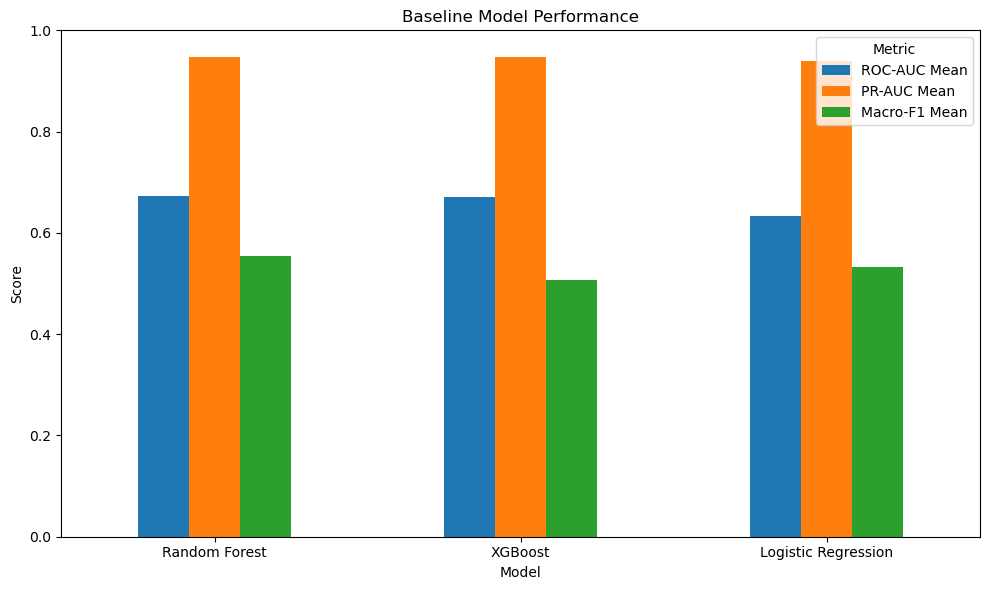

In [17]:
# BASELINE MODEL COMPARISON PLOT
import matplotlib.pyplot as plt

plot_df = baseline_results_df.set_index("Model")[
    ["ROC-AUC Mean", "PR-AUC Mean", "Macro-F1 Mean"]
]

plot_df.plot(kind="bar", figsize=(10, 6))

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Baseline Model Performance")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [19]:
# Define manually selected Random Forest hyperparameter configurations
rf_configs = {
    "RF_1": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    "RF_2": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    "RF_3": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_split": 5,
        "min_samples_leaf": 1
    },

    "RF_4": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    },

    "RF_5": {
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    }
}

In [24]:
# Evaluate Random Forest configurations using stratified 5-fold cross-validation
from sklearn.model_selection import cross_validate

rf_tuning_results = []

for name, params in rf_configs.items():
    
    print(f"Running {name}...")
    
    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1_macro": "f1_macro"
        },
        n_jobs=1,
        return_train_score=False
    )
    
    rf_tuning_results.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "Macro F1": scores["test_f1_macro"].mean()
    })
    
    print(
        f"ROC-AUC: {scores['test_roc_auc'].mean():.4f} ± "
        f"{scores['test_roc_auc'].std():.4f}"
    )

print("\nTuning complete.")

Running RF_1...
ROC-AUC: 0.6547 ± 0.0104
Running RF_2...
ROC-AUC: 0.6706 ± 0.0177
Running RF_3...
ROC-AUC: 0.6777 ± 0.0133
Running RF_4...
ROC-AUC: 0.6812 ± 0.0167
Running RF_5...
ROC-AUC: 0.6829 ± 0.0161

Tuning complete.


In [25]:
# Summarize Random Forest tuning results

results_df = pd.DataFrame(rf_tuning_results)

print(results_df.sort_values("ROC-AUC", ascending=False).to_string(index=False))


Model  ROC-AUC  ROC-AUC SD   PR-AUC  Macro F1
 RF_5 0.682861    0.016068 0.948750  0.481292
 RF_4 0.681216    0.016695 0.948484  0.481326
 RF_3 0.677675    0.013348 0.948440  0.485119
 RF_2 0.670556    0.017665 0.947313  0.491639
 RF_1 0.654686    0.010412 0.943806  0.524106


In [26]:
# Select the best-performing Random Forest configuration based on ROC-AUC
# Train the final tuned Random Forest on the complete training set
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    
    random_state=42,
    n_jobs=-1
)

In [27]:
# Generate predictions for the held-out test set
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]


In [28]:
# Evaluate final model performance on the held-out test set
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


print("Final Tuned Random Forest — Test Set")
print("------------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_rf):.4f}")



Final Tuned Random Forest — Test Set
------------------------------------
Accuracy:  0.7741
Precision: 0.9424
Recall:    0.8004
F1-score:  0.8656
ROC-AUC:   0.7321
PR-AUC:    0.9602


In [29]:
# Examine class-specific performance and prediction errors
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["inactive", "active"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

    inactive       0.20      0.51      0.29       282
      active       0.94      0.80      0.87      2821

    accuracy                           0.77      3103
   macro avg       0.57      0.66      0.58      3103
weighted avg       0.88      0.77      0.81      3103

Confusion Matrix:
[[ 144  138]
 [ 563 2258]]


In [ ]:
# Save the final trained model for downstream virtual screening
import joblib

joblib.dump(best_rf, "final_random_forest.pkl")

print("Final RF model saved as final_random_forest.pkl")

In [ ]:
# Save Random Forest tuning results
results_df.to_csv(
    RESULTS_DIR/"Model Performance"/"rf_tuning_results.csv"),
    index=False
)



In [ ]:
# Save final test-set performance metrics
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        roc_auc_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_rf)
    ]
})

final_metrics.to_csv(
    RESULTS_DIR/"Model Performance"/"rf_final_test_metrics",
    index=False
)

print(final_metrics)
